In [71]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from matplotlib.colors import LogNorm

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

In [72]:
# A)
x1, x2 = sp.symbols('x1 x2', real=True)

EL_sym = x1**2 / sp.Rational(3,2) + x2**2 / sp.Rational(3,2) + \
         3 * sp.sin((x1 + x2) / sp.sqrt(2))**2

grad_EL_sym = sp.Matrix([sp.diff(EL_sym, x1), sp.diff(EL_sym, x2)])
hess_EL_sym = sp.hessian(EL_sym, [x1, x2])

grad_EL_sym, hess_EL_sym

(Matrix([
 [4*x1/3 + 3*sqrt(2)*sin(sqrt(2)*(x1 + x2)/2)*cos(sqrt(2)*(x1 + x2)/2)],
 [4*x2/3 + 3*sqrt(2)*sin(sqrt(2)*(x1 + x2)/2)*cos(sqrt(2)*(x1 + x2)/2)]]),
 Matrix([
 [-3*sin(sqrt(2)*(x1 + x2)/2)**2 + 3*cos(sqrt(2)*(x1 + x2)/2)**2 + 4/3,       -3*sin(sqrt(2)*(x1 + x2)/2)**2 + 3*cos(sqrt(2)*(x1 + x2)/2)**2],
 [      -3*sin(sqrt(2)*(x1 + x2)/2)**2 + 3*cos(sqrt(2)*(x1 + x2)/2)**2, -3*sin(sqrt(2)*(x1 + x2)/2)**2 + 3*cos(sqrt(2)*(x1 + x2)/2)**2 + 4/3]]))

In [73]:
ER_sym = (1 - x1)**2 + 100*(x2 - x1**2)**2

grad_ER_sym = sp.Matrix([sp.diff(ER_sym, x1), sp.diff(ER_sym, x2)])
hess_ER_sym = sp.hessian(ER_sym, [x1, x2])

grad_ER_sym, hess_ER_sym

(Matrix([
 [-400*x1*(-x1**2 + x2) + 2*x1 - 2],
 [             -200*x1**2 + 200*x2]]),
 Matrix([
 [1200*x1**2 - 400*x2 + 2, -400*x1],
 [                -400*x1,     200]]))

In [74]:
args = [x1, x2]

EL_fn  = sp.lambdify(args, EL_sym,       'numpy')
gEL_fn = sp.lambdify(args, grad_EL_sym,  'numpy')
HEL_fn = sp.lambdify(args, hess_EL_sym,  'numpy')

ER_fn  = sp.lambdify(args, ER_sym,       'numpy')
gER_fn = sp.lambdify(args, grad_ER_sym,  'numpy')
HER_fn = sp.lambdify(args, hess_ER_sym,  'numpy')

def grad_EL(x): return np.array(gEL_fn(x[0], x[1]), dtype=float).flatten()
def hess_EL(x): return np.array(HEL_fn(x[0], x[1]), dtype=float)

def grad_ER(x): return np.array(gER_fn(x[0], x[1]), dtype=float).flatten()
def hess_ER(x): return np.array(HER_fn(x[0], x[1]), dtype=float)

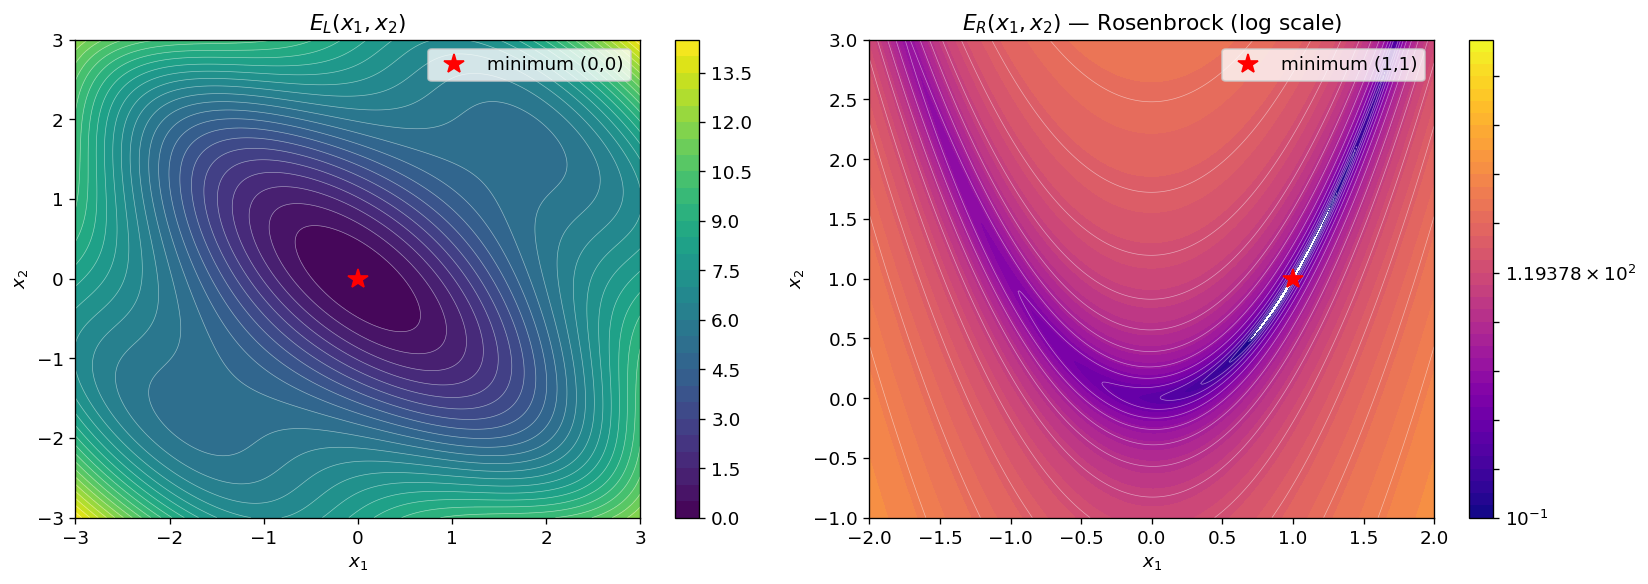

In [75]:
# B)

def make_grid(xlim, ylim, n=400):
    
    xs = np.linspace(*xlim, n)
    ys = np.linspace(*ylim, n)
    X, Y = np.meshgrid(xs, ys)
    return X, Y

# EL Grid
XL, YL = make_grid((-3, 3), (-3, 3))
ZL = EL_fn(XL, YL)

# ER Grid
XR, YR = make_grid((-2, 2), (-1, 3))
ZR = ER_fn(XR, YR)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# EL contour
ax = axes[0]
cp = ax.contourf(XL, YL, ZL, levels=30, cmap='viridis')
ax.contour(XL, YL, ZL, levels=30, colors='white', linewidths=0.4, alpha=0.5)
fig.colorbar(cp, ax=ax)
ax.set_title(r'$E_L(x_1,x_2)$', fontsize=13)
ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
ax.plot(0, 0, 'r*', markersize=12, label='minimum (0,0)')
ax.legend()

# ER contour
ax = axes[1]
cp = ax.contourf(XR, YR, ZR, levels=np.logspace(-1, 5, 40), norm=LogNorm(), cmap='plasma')
ax.contour(XR, YR, ZR, levels=np.logspace(-1, 5, 20), norm=LogNorm(),
           colors='white', linewidths=0.4, alpha=0.5)
fig.colorbar(cp, ax=ax)
ax.set_title(r'$E_R(x_1,x_2)$ — Rosenbrock (log scale)', fontsize=13)
ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
ax.plot(1, 1, 'r*', markersize=12, label='minimum (1,1)')
ax.legend()

plt.tight_layout()
plt.show()

In [76]:
# C)

def newton_method(grad_fn, hess_fn, x0, eps=1e-4, max_iter=1000, max_step=0.5):
    x = np.array(x0, dtype=float)
    path = [x.copy()]

    for _ in range(max_iter):
        g = grad_fn(x)
        H = hess_fn(x)
        step = np.linalg.solve(H, g)


        # step damping to avoid divergence far from minimum
        step_norm = np.linalg.norm(step)
        if step_norm > max_step:
            step = step * (max_step / step_norm)

        x_new = x - step
        path.append(x_new.copy())

        if np.linalg.norm(x_new - x) < eps:
            return path, True
        x = x_new

    return path, False

In [77]:
# D)

np.random.seed(42)


# EL: avoid exact zero which is already the minimum
starts_L = [
    np.array([ 1.5,  1.0]),
    np.array([-1.0,  2.0]),
    np.array([-2.0, -1.5]),
    np.array([ 0.5, -2.0]),
]

# ER: Rosenbrock. Start near but not at (1,1)
starts_R = [np.array([-1.5,  2.0]),
            np.array([ 0.5, -0.5]),
            np.array([-0.5,  1.5]),
            np.array([ 1.5,  0.5])]

print("Starting points for EL:", [s.tolist() for s in starts_L])
print("Starting points for ER:", [s.tolist() for s in starts_R])

Starting points for EL: [[1.5, 1.0], [-1.0, 2.0], [-2.0, -1.5], [0.5, -2.0]]
Starting points for ER: [[-1.5, 2.0], [0.5, -0.5], [-0.5, 1.5], [1.5, 0.5]]


In [78]:
results_L = []
print("Results for EL (minimum at (0,0)):")
for i, x0 in enumerate(starts_L):
    path, conv = newton_method(grad_EL, hess_EL, x0, eps=1e-4)
    results_L.append(path)
    xf = path[-1]
    print(f"  Start {i+1}: {np.round(x0,4)} → {np.round(xf,6)}  "
          f"({'converged' if conv else 'NOT converged'}, {len(path)-1} steps)")

Results for EL (minimum at (0,0)):
  Start 1: [1.5 1. ] → [1.630661 1.630661]  (NOT converged, 1000 steps)
  Start 2: [-1.  2.] → [-0. -0.]  (converged, 7 steps)
  Start 3: [-2.  -1.5] → [-1.580315 -1.580315]  (NOT converged, 1000 steps)
  Start 4: [ 0.5 -2. ] → [-1.628793 -1.628793]  (NOT converged, 1000 steps)


In [79]:
results_R = []
print("Results for ER (minimum at (1,1)):")
for i, x0 in enumerate(starts_R):
    path, conv = newton_method(grad_ER, hess_ER, x0, eps=1e-4)
    results_R.append(path)
    xf = path[-1]
    print(f"  Start {i+1}: {np.round(x0,4)} → {np.round(xf,6)}  "
          f"({'converged' if conv else 'NOT converged'}, {len(path)-1} steps)")

Results for ER (minimum at (1,1)):
  Start 1: [-1.5  2. ] → [1. 1.]  (converged, 17 steps)
  Start 2: [ 0.5 -0.5] → [1. 1.]  (converged, 8 steps)
  Start 3: [-0.5  1.5] → [1. 1.]  (converged, 13 steps)
  Start 4: [1.5 0.5] → [1. 1.]  (converged, 12 steps)


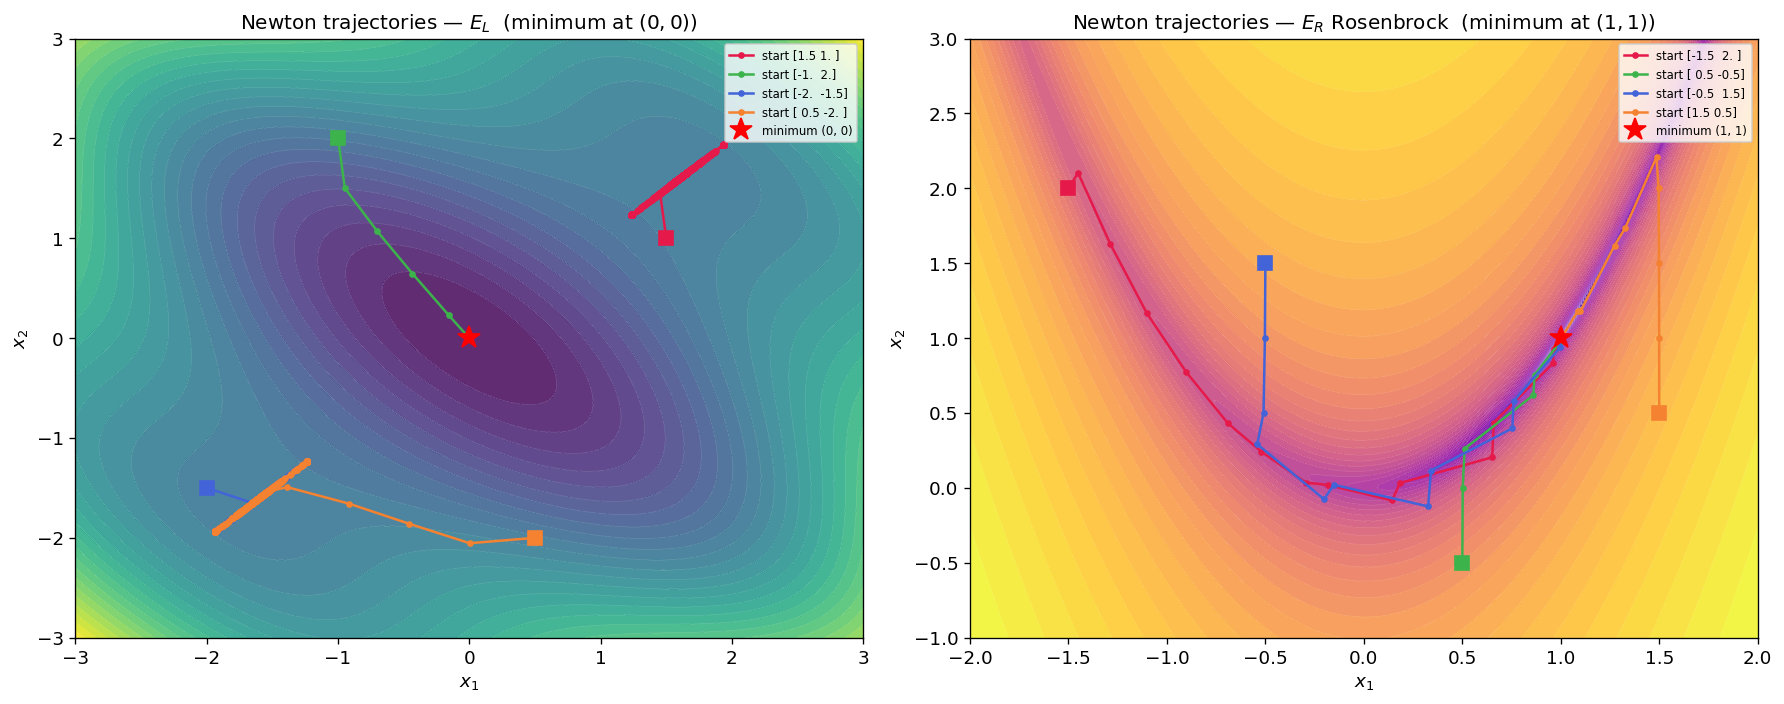

In [80]:
COLORS = ['#e6194b', '#3cb44b', '#4363d8', '#f58231']

def plot_trajectories(ax, paths, starts, minimum, title, X, Y, Z,
                      log_scale=False):
    if log_scale:
        levels = np.logspace(np.log10(max(Z.min(), 1e-2)), np.log10(Z.max()), 40)
        ax.contourf(X, Y, Z, levels=levels, norm=LogNorm(), cmap='plasma', alpha=0.85)
        ax.contour(X, Y, Z, levels=levels, norm=LogNorm(),
                   colors='white', linewidths=0.3, alpha=0.4)
    else:
        ax.contourf(X, Y, Z, levels=30, cmap='viridis', alpha=0.85)
        ax.contour(X, Y, Z, levels=30, colors='white', linewidths=0.3, alpha=0.4)

    for path, x0, col in zip(paths, starts, COLORS):
        pts = np.array(path)
        ax.plot(pts[:, 0], pts[:, 1], '-o', color=col,
                markersize=3, linewidth=1.5, label=f'start {np.round(x0,2)}')
        ax.plot(x0[0], x0[1], 's', color=col, markersize=8)  # start marker

    ax.plot(*minimum, 'r*', markersize=14, zorder=5, label=f'minimum {minimum}')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
    ax.legend(fontsize=7, loc='upper right')


fig, axes = plt.subplots(1, 2, figsize=(15, 6))

plot_trajectories(axes[0], results_L, starts_L, (0, 0),
                  r'Newton trajectories — $E_L$  (minimum at $(0,0)$)',
                  XL, YL, ZL, log_scale=False)

plot_trajectories(axes[1], results_R, starts_R, (1, 1),
                  r'Newton trajectories — $E_R$ Rosenbrock  (minimum at $(1,1)$)',
                  XR, YR, ZR, log_scale=True)

plt.tight_layout()
plt.show()

Gradient at x = [1,1]: [5. 8.]
Hessian (constant):
 [[3. 2.]
 [2. 6.]]


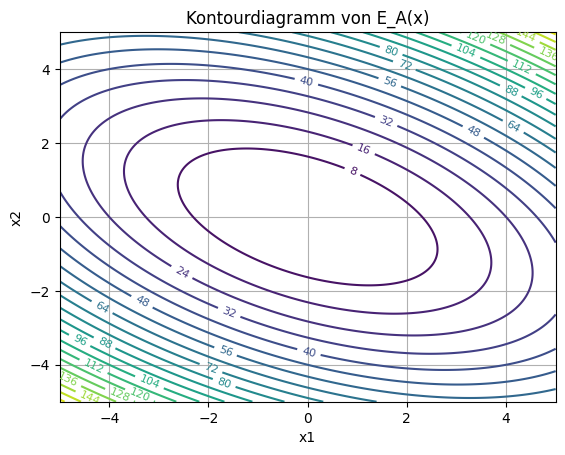

In [2]:
#2A

import numpy as np
import matplotlib.pyplot as plt

# ---------- Matrix A ----------
A = np.array([[3, 2],
              [2, 6]], dtype=float)

# ---------- Symbolic-style definitions ----------
def E(x):
    return 0.5 * x.T @ A @ x

def grad_E(x):
    return A @ x

def hessian_E(x):
    return A  # constant for quadratic function

# ---------- Test at a sample point ----------
x_test = np.array([1.0, 1.0])

print("Gradient at x = [1,1]:", grad_E(x_test))
print("Hessian (constant):\n", hessian_E(x_test))

# ---------- Contour Plot ----------
def E_grid(x1, x2):
    return 0.5 * (3*x1**2 + 4*x1*x2 + 6*x2**2)

# Grid
x1 = np.linspace(-5, 5, 200)
x2 = np.linspace(-5, 5, 200)
X1, X2 = np.meshgrid(x1, x2)

Z = E_grid(X1, X2)

# Plot
plt.figure()
contours = plt.contour(X1, X2, Z, levels=20)
plt.clabel(contours, inline=True, fontsize=8)

plt.title("Kontourdiagramm von E_A(x)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid()

plt.show()

Eigenvalues: [2. 7.]

h = 0.01
Last point: [ 2.8438 -1.6561]

h = 0.05
Last point: [ 0.5349 -0.2676]

h = 0.1
Last point: [ 0.0507 -0.0254]

h = 0.2
Last point: [ 0.0002 -0.0001]

h = 0.3
Last point: [-2.691 -5.382]


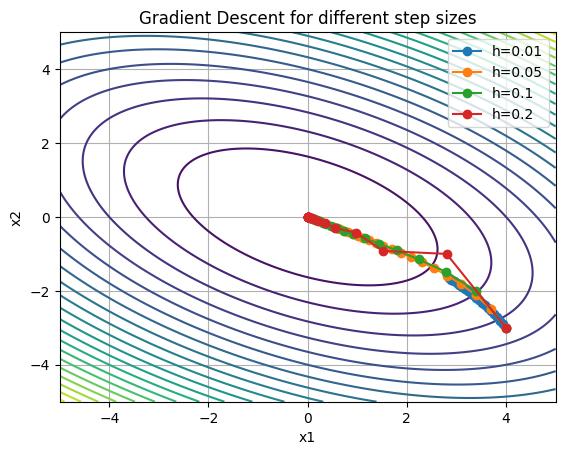

In [4]:
#2B

eigvals = np.linalg.eigvals(A)
print("Eigenvalues:", eigvals)

def gradient_descent(A, x0, h, steps):
    x = x0.copy()
    trajectory = [x.copy()]

    for _ in range(steps):
        grad = A @ x
        x = x - h * grad
        trajectory.append(x.copy())

    return np.array(trajectory)

x0 = np.array([4.0, -3.0])

step_sizes = [0.01, 0.05, 0.1, 0.2, 0.3]

for h in step_sizes:
    traj = gradient_descent(A, x0, h, 20)
    print(f"\nh = {h}")
    print("Last point:", np.round(traj[-1], 4))
    

plt.figure()

# contour
plt.contour(X1, X2, Z, levels=20)

for h in [0.01, 0.05, 0.1, 0.2]:
    traj = gradient_descent(A, x0, h, 20)
    plt.plot(traj[:,0], traj[:,1], marker='o', label=f"h={h}")

plt.legend()
plt.title("Gradient Descent for different step sizes")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid()

plt.show()    

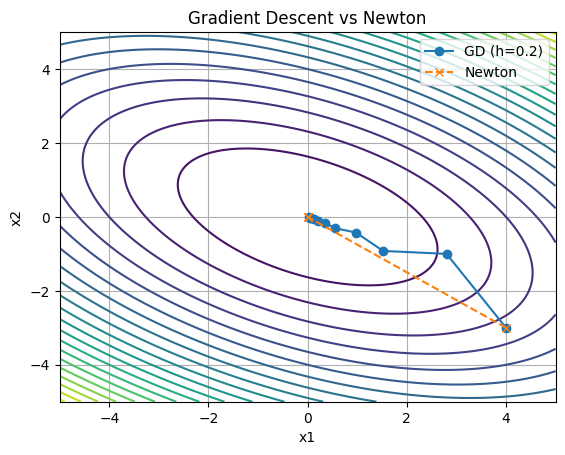

In [ ]:
#2C
import numpy as np
import matplotlib.pyplot as plt

A = np.array([[3, 2],
              [2, 6]], dtype=float)

# ---------- Gradient Descent ----------
def gradient_descent(A, x0, h, steps):
    x = x0.copy()
    traj = [x.copy()]
    
    for _ in range(steps):
        x = x - h * (A @ x)
        traj.append(x.copy())
        
    return np.array(traj)

# ---------- Newton Method ----------
def newton_method(A, x0, steps):
    x = x0.copy()
    traj = [x.copy()]
    
    A_inv = np.linalg.inv(A)
    
    for _ in range(steps):
        x = x - A_inv @ (A @ x)
        traj.append(x.copy())
        
    return np.array(traj)

# ---------- Contour ----------
def E(x1, x2):
    return 0.5 * (3*x1**2 + 4*x1*x2 + 6*x2**2)

x1 = np.linspace(-5, 5, 200)
x2 = np.linspace(-5, 5, 200)
X1, X2 = np.meshgrid(x1, x2)
Z = E(X1, X2)

# ---------- Start point ----------
x0 = np.array([4.0, -3.0])

# ---------- Compute trajectories ----------
gd_traj = gradient_descent(A, x0, h=0.2, steps=10)
newton_traj = newton_method(A, x0, steps=3)

# ---------- Plot ----------
plt.figure()

# Contours
plt.contour(X1, X2, Z, levels=20)

# GD path
plt.plot(gd_traj[:,0], gd_traj[:,1], marker='o', label='GD (h=0.2)')

# Newton path
plt.plot(newton_traj[:,0], newton_traj[:,1], marker='x', linestyle='--', label='Newton')

plt.legend()
plt.title("Gradient Descent vs Newton")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid()

plt.show()

=== EL Experiments ===
h = 0.001, last point: [ 1.3455 -0.9932]
h = 0.01, last point: [ 0.6447 -0.6331]
h = 0.05, last point: [ 0.0397 -0.0397]
h = 0.1, last point: [ 0.001 -0.001]


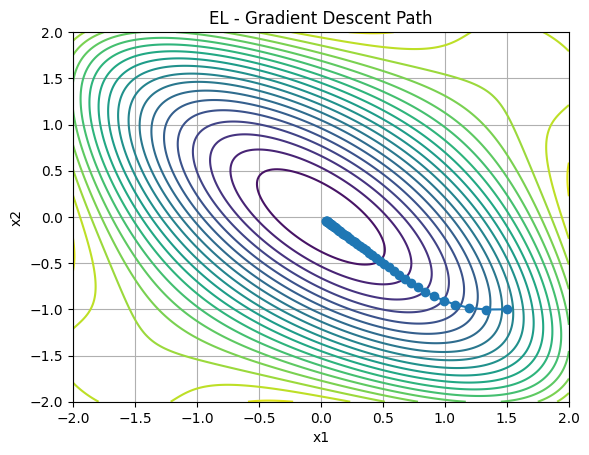


=== ER Experiments ===
h = 0.0001, last point: [-1.2446  1.5567]
h = 0.001, last point: [-1.1102  1.2405]
h = 0.005, last point: [ 1735.2812 17741.1141]
h = 0.01, last point: [  -69.9215 35655.605 ]


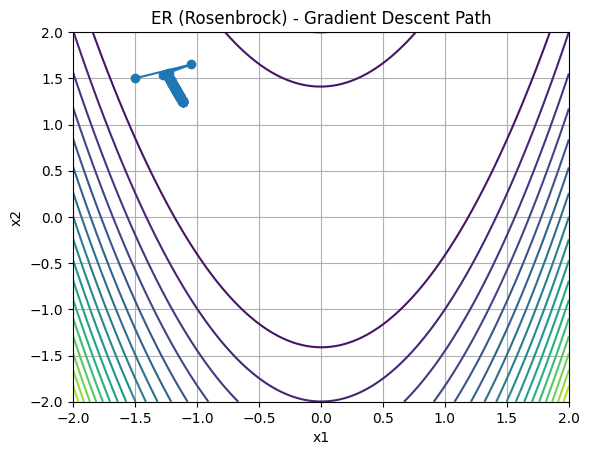

In [14]:
#3A

import numpy as np
import matplotlib.pyplot as plt

# ---------- EL ----------
def EL(x):
    x1, x2 = x
    return (x1**2)/1.5 + (x2**2)/1.5 + 3 * np.sin((x1 + x2)/np.sqrt(2))**2

def grad_EL(x):
    x1, x2 = x
    
    d1 = (2*x1)/1.5
    d2 = (2*x2)/1.5
    
    trig = 3 * np.sin(2*(x1 + x2)/np.sqrt(2)) / np.sqrt(2)
    
    return np.array([d1 + trig, d2 + trig])


# ---------- ER (Rosenbrock) ----------
def ER(x):
    x1, x2 = x
    return (1 - x1)**2 + 100*(x2 - x1**2)**2

def grad_ER(x):
    x1, x2 = x
    # Clip x1 and x2 to avoid overflow
    x1 = np.clip(x1, -10, 10)
    x2 = np.clip(x2, -10, 10)
    d1 = -2*(1 - x1) - 400*x1*(x2 - x1**2)
    d2 = 200*(x2 - x1**2)
    return np.array([d1, d2])


# ---------- Gradient Descent ----------
def gradient_descent(grad, x0, h, steps):
    x = x0.copy()
    traj = [x.copy()]
    
    for _ in range(steps):
        x = x - h * grad(x)
        traj.append(x.copy())
        
    return np.array(traj)


# ---------- Contour Plot ----------
def plot_contour(E, traj, title, x_range=(-2,2), y_range=(-2,2)):
    x1 = np.linspace(x_range[0], x_range[1], 200)
    x2 = np.linspace(y_range[0], y_range[1], 200)
    X1, X2 = np.meshgrid(x1, x2)
    
    Z = np.array([[E([x, y]) for x in x1] for y in x2])
    
    plt.figure()
    plt.contour(X1, X2, Z, levels=20)
    plt.plot(traj[:,0], traj[:,1], marker='o')
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.grid()
    plt.show()


# ---------- Experiments ----------

# --- EL ---
print("=== EL Experiments ===")
x0_EL = np.array([1.5, -1.0])

for h in [0.001, 0.01, 0.05, 0.1]:
    traj = gradient_descent(grad_EL, x0_EL, h, 50)
    print(f"h = {h}, last point:", np.round(traj[-1], 4))

# Plot one example
traj_EL = gradient_descent(grad_EL, x0_EL, 0.05, 50)
plot_contour(EL, traj_EL, "EL - Gradient Descent Path")


# --- ER (Rosenbrock) ---
print("\n=== ER Experiments ===")
x0_ER = np.array([-1.5, 1.5])

for h in [0.0001, 0.001, 0.005, 0.01]:
    traj = gradient_descent(grad_ER, x0_ER, h, 200)
    print(f"h = {h}, last point:", np.round(traj[-1], 4))

# Plot one example
traj_ER = gradient_descent(grad_ER, x0_ER, 0.001, 200)
plot_contour(ER, traj_ER, "ER (Rosenbrock) - Gradient Descent Path")

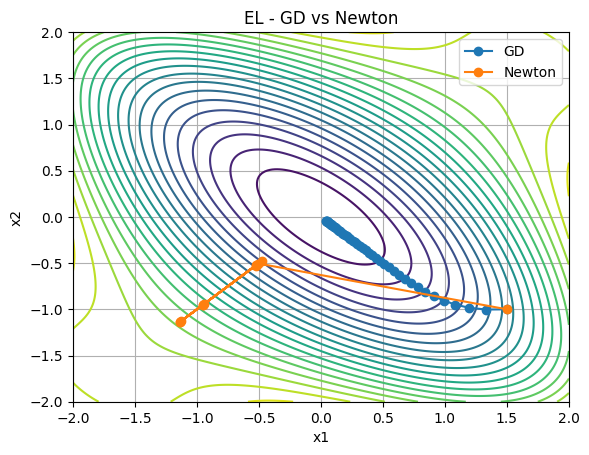

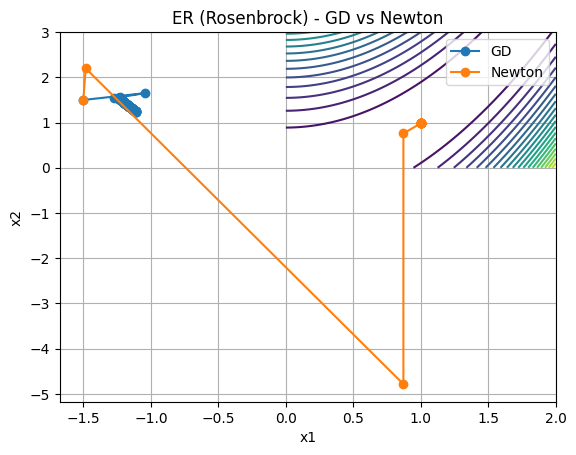

In [16]:
#3B
import numpy as np
import matplotlib.pyplot as plt

# ---------- EL ----------
def EL(x):
    x1, x2 = x
    return (x1**2)/1.5 + (x2**2)/1.5 + 3 * np.sin((x1 + x2)/np.sqrt(2))**2

def grad_EL(x):
    x1, x2 = x
    d1 = (2*x1)/1.5
    d2 = (2*x2)/1.5
    trig = 3 * np.sin(2*(x1 + x2)/np.sqrt(2)) / np.sqrt(2)
    return np.array([d1 + trig, d2 + trig])

def hess_EL(x):
    x1, x2 = x
    # Quadratic part
    H = np.array([[2/1.5, 0], [0, 2/1.5]])
    # Trig part
    trig_factor = 6 * (np.cos(2*(x1 + x2)/np.sqrt(2))**2 - np.sin(2*(x1 + x2)/np.sqrt(2))**2) / 2
    H += np.array([[trig_factor, trig_factor], [trig_factor, trig_factor]])
    return H

# ---------- ER (Rosenbrock) ----------
def ER(x):
    x1, x2 = x
    return (1 - x1)**2 + 100*(x2 - x1**2)**2

def grad_ER(x):
    x1, x2 = x
    d1 = -2*(1 - x1) - 400*x1*(x2 - x1**2)
    d2 = 200*(x2 - x1**2)
    return np.array([d1, d2])

def hess_ER(x):
    x1, x2 = x
    H = np.array([
        [2 - 400*x2 + 1200*x1**2, -400*x1],
        [-400*x1, 200]
    ])
    return H

# ---------- Gradient Descent ----------
def gradient_descent(grad, x0, h, steps):
    x = x0.copy()
    traj = [x.copy()]
    for _ in range(steps):
        x_new = x - h * grad(x)
        if np.any(np.isnan(x_new)) or np.any(np.isinf(x_new)):
            break
        x = x_new
        traj.append(x.copy())
    return np.array(traj)

# ---------- Newton Method ----------
def newton_method(grad, hess, x0, steps):
    x = x0.copy()
    traj = [x.copy()]
    for _ in range(steps):
        H = hess(x)
        g = grad(x)
        # Solve H * p = g  => p = H^{-1} g
        try:
            delta = np.linalg.solve(H, g)
        except np.linalg.LinAlgError:
            break
        x_new = x - delta
        if np.any(np.isnan(x_new)) or np.any(np.isinf(x_new)):
            break
        x = x_new
        traj.append(x.copy())
    return np.array(traj)

# ---------- Plotting ----------
def plot_contour(E, trajs, labels, x_range, y_range, title):
    x1 = np.linspace(x_range[0], x_range[1], 200)
    x2 = np.linspace(y_range[0], y_range[1], 200)
    X1, X2 = np.meshgrid(x1, x2)
    Z = np.zeros_like(X1)
    for i in range(X2.shape[0]):
        for j in range(X1.shape[1]):
            val = E([X1[i,j], X2[i,j]])
            if np.isfinite(val):
                Z[i,j] = val
            else:
                Z[i,j] = np.nan

    plt.figure()
    plt.contour(X1, X2, Z, levels=20)
    for traj, label in zip(trajs, labels):
        plt.plot(traj[:,0], traj[:,1], marker='o', label=label)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.grid()
    plt.show()

# ---------- Experiments ----------

# --- EL ---
x0_EL = np.array([1.5, -1.0])
traj_EL_GD = gradient_descent(grad_EL, x0_EL, h=0.05, steps=50)
traj_EL_Newton = newton_method(grad_EL, hess_EL, x0_EL, steps=10)

plot_contour(
    EL,
    [traj_EL_GD, traj_EL_Newton],
    ["GD", "Newton"],
    x_range=(-2,2),
    y_range=(-2,2),
    title="EL - GD vs Newton"
)

# --- ER (Rosenbrock) ---
x0_ER = np.array([-1.5, 1.5])
traj_ER_GD = gradient_descent(grad_ER, x0_ER, h=0.001, steps=200)
traj_ER_Newton = newton_method(grad_ER, hess_ER, x0_ER, steps=20)

plot_contour(
    ER,
    [traj_ER_GD, traj_ER_Newton],
    ["GD", "Newton"],
    x_range=(0,2),
    y_range=(0,3),
    title="ER (Rosenbrock) - GD vs Newton"
)